In [ ]:
!pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.4/491.4 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 15.2 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.2 requires fsspec==2025.3.2, but you have fsspec 2025.3.0 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is

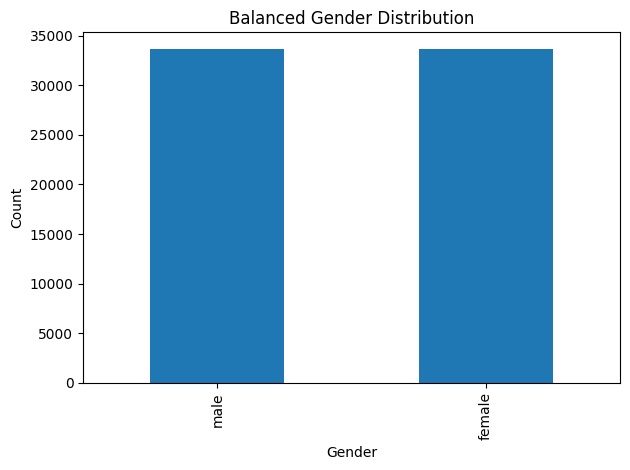

,gender,transcription_normalised
0,male,not reach them bhil meenas were at the bottom ...
1,male,for the second code may be you have an optimal...
2,male,soils as well as it it helps to get a clean
3,male,so from goals you are moving to sub goals esse...
4,male,will be known to you right then that is why ac...
...,...,...
67325,female,zero what is it that we did in the abstract op...
67326,female,so one has to out way which one is giving the ...
67327,female,basically the training sample wherein we have ...
67328,female,like you to discuss what are the different way...


from matplotlib import pyplot as plt
_df_0['index'].plot(kind='hist', bins=20, title='index')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['index']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': 'index'}, axis=1)
              .sort_values('index', ascending=True))
  xs = counted['index']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_1.sort_values('index', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('index')
_ = plt.ylabel('count()')

from matplotlib import pyplot as plt
_df_2['index'].plot(kind='line', figsize=(8, 4), title='index')
plt.gca().spines[['top', 'right']].set_visible(False)

In [ ]:
from datasets import load_dataset
import pandas as pd
from sklearn.utils import resample
import matplotlib.pyplot as plt

dataset = load_dataset("kaushalgawri/nptel-en-tags-and-gender-v0", split="train")
df = dataset.to_pandas()[["gender", "transcription_normalised"]]

df["gender"] = df["gender"].str.lower()

df = df[df["gender"].isin(["male", "female"])]

min_count = df["gender"].value_counts().min()
df_male = resample(df[df["gender"] == "male"], n_samples=min_count, random_state=42)
df_female = resample(df[df["gender"] == "female"], n_samples=min_count, random_state=42)
df = pd.concat([df_male, df_female]).reset_index(drop=True)

df["gender"].value_counts().plot(kind="bar", title="Balanced Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

df

In [ ]:
import pickle

with open("nptel_gender_balanced.pkl", "wb") as f:
    pickle.dump(df, f)